# FIFA World Cup 2026 — End-to-End ML Pipeline (CRISP-DM)

This single notebook trains the prediction models and exports JSON artifacts
consumed by the Next.js site. Run **Kernel → Restart & Run All** to reproduce
everything from raw Kaggle data to deployable JSON.

**Pipeline stages (CRISP-DM):**
1. Business Understanding — objectives, format, success criteria
2. Data Understanding — Kaggle download, schema, EDA
3. Data Preparation — Elo, features, time-based split
4. Modeling — XGBoost classifier + Dixon-Coles Poisson goals + ensemble + calibration
5. Evaluation — log-loss, Brier, RPS, calibration plot, WC 2022 backtest
6. Deployment — JSON artifact export to `web/public/data/`

Hardware target: laptop with RTX 2050 / 16 GB RAM. XGBoost runs on CPU in seconds
on this dataset (~50k matches); GPU is optional.

## Phase 1 — Business Understanding

**Goal.** Calibrated probabilities for every WC 2026 match plus tournament-level
probabilities (group qualification, knockout progression, championship) via Monte
Carlo simulation.

**Tournament format (2026 — first 48-team edition).**
- 48 teams, 12 groups of 4 (labels A–L)
- Top 2 of each group + 8 best third-placed teams → Round of 32
- 104 matches total: 72 group + 16 R32 + 8 R16 + 4 QF + 2 SF + 3rd-place + final
- Hosts: USA, Mexico, Canada. Host advantage modeled only for those three;
  every other fixture is treated as neutral venue.

**Success criteria.**
- Beat an **Elo-only logistic** baseline on log-loss, Brier score, and
  **RPS** (Ranked Probability Score — the standard metric for ordered
  football outcomes) on a held-out time-based test set (2022–2025).
- Reliability curve close to the diagonal (well-calibrated probabilities).
- WC 2022 backtest produces sensible champion odds.

**Risk / honesty.** Football outcomes are high-variance. A "good" classifier on
this task hits ~0.96–1.00 log-loss; the value is calibration, not certainty.

## Phase 2 — Data Understanding

Two Kaggle datasets:

| Source | What | Notes |
|---|---|---|
| `martj42/international-football-results-from-1872-to-2017` | All international matches | Updated continuously despite the name; ~48k rows |
| `cashncarry/fifaworldranking` | FIFA ranking points over time | Joinable by team + date |

The WC 2026 team list and group draw live in `data/raw/wc2026_teams.json`
(hand-curated for the project — see file header).

### 2.1 Setup

In [1]:
import os, sys, json, warnings, math, hashlib
from pathlib import Path
from datetime import date, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 50
sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(42)

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
ART = ROOT / "artifacts"
WEB_DATA = ROOT / "web" / "public" / "data"
for d in (RAW, PROC, ART, WEB_DATA):
    d.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

Project root: C:\Users\amine\Desktop\Project World Cup 2026


In [2]:
# Verify Kaggle credentials. Either form works:
#   ~/.kaggle/kaggle.json      (legacy username+key JSON)
#   ~/.kaggle/access_token     (newer single-token format, KGAT_...)
KAGGLE_DIR = Path.home() / ".kaggle"
legacy = KAGGLE_DIR / "kaggle.json"
modern = KAGGLE_DIR / "access_token"
if legacy.exists() or modern.exists():
    print(f"Kaggle token OK ({'access_token' if modern.exists() else 'kaggle.json'})")
else:
    print(f"!! No Kaggle token in {KAGGLE_DIR}.")
    print("   Visit https://www.kaggle.com/settings/account, create a token,")
    print("   save it at one of the paths above, then re-run this cell.")

Kaggle token OK (access_token)


In [3]:
import subprocess

def kaggle_download(slug: str, target: Path):
    target.mkdir(parents=True, exist_ok=True)
    sentinel = target / ".downloaded"
    if sentinel.exists():
        print(f"  cached: {slug}")
        return
    print(f"  downloading {slug} ...")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", slug, "-p", str(target), "--unzip"],
        check=True,
    )
    sentinel.touch()

kaggle_download("martj42/international-football-results-from-1872-to-2017", RAW / "results")
kaggle_download("cashncarry/fifaworldranking", RAW / "fifa_ranking")
print("Done.")

  cached: martj42/international-football-results-from-1872-to-2017
  cached: cashncarry/fifaworldranking
Done.


In [4]:
# Locate CSVs (filenames sometimes change between dataset versions)
def find_csv(folder: Path, hint: str):
    for p in folder.rglob("*.csv"):
        if hint in p.name.lower():
            return p
    return None

results_csv = find_csv(RAW / "results", "results")
shootouts_csv = find_csv(RAW / "results", "shootout")
ranking_csv = find_csv(RAW / "fifa_ranking", "ranking") or find_csv(RAW / "fifa_ranking", "fifa")

print("results:  ", results_csv)
print("shootouts:", shootouts_csv)
print("ranking:  ", ranking_csv)

matches = pd.read_csv(results_csv, parse_dates=["date"])
shootouts = pd.read_csv(shootouts_csv, parse_dates=["date"]) if shootouts_csv else pd.DataFrame()
ranking = pd.read_csv(ranking_csv)
date_col = next((c for c in ranking.columns if "date" in c.lower()), None)
ranking[date_col] = pd.to_datetime(ranking[date_col])
ranking = ranking.rename(columns={date_col: "date"})
print(f"matches: {len(matches):,}   shootouts: {len(shootouts):,}   ranking rows: {len(ranking):,}")
matches.head()

results:   C:\Users\amine\Desktop\Project World Cup 2026\data\raw\results\results.csv
shootouts: C:\Users\amine\Desktop\Project World Cup 2026\data\raw\results\shootouts.csv
ranking:   C:\Users\amine\Desktop\Project World Cup 2026\data\raw\fifa_ranking\fifa_ranking-2023-07-20.csv
matches: 49,472   shootouts: 678   ranking rows: 64,757


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### 2.2 EDA

Dropped 72 unplayed/NaN-score matches; 30692 remain
Matches since 1993: 30692

Result distribution (all venues):
result
H    0.486
A    0.281
D    0.233
Name: proportion, dtype: float64

Result distribution (NEUTRAL venue only):
result
H    0.426
A    0.339
D    0.234
Name: proportion, dtype: float64


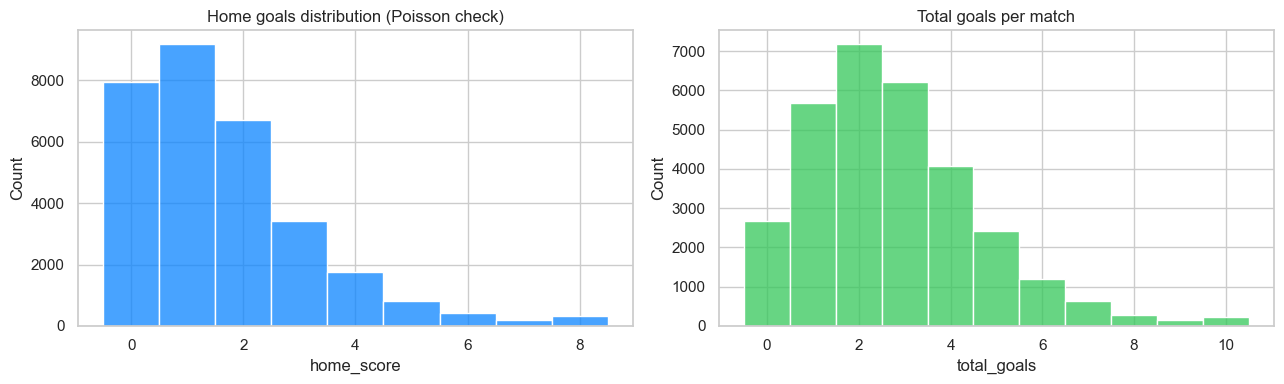

In [5]:
modern = matches[matches["date"] >= "1993-01-01"].copy()
# Drop unplayed future fixtures (the Kaggle file now includes them with NaN scores)
before = len(modern)
modern = modern.dropna(subset=["home_score", "away_score"])
modern["home_score"] = modern["home_score"].astype(int)
modern["away_score"] = modern["away_score"].astype(int)
print(f"Dropped {before - len(modern)} unplayed/NaN-score matches; {len(modern)} remain")
modern["total_goals"] = modern["home_score"] + modern["away_score"]
modern["result"] = np.where(modern["home_score"] > modern["away_score"], "H",
                    np.where(modern["home_score"] < modern["away_score"], "A", "D"))

print("Matches since 1993:", len(modern))
print("\nResult distribution (all venues):")
print(modern["result"].value_counts(normalize=True).round(3))
print("\nResult distribution (NEUTRAL venue only):")
print(modern[modern["neutral"]]["result"].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(modern["home_score"].clip(0, 8), discrete=True, ax=axes[0], color="#0a84ff")
axes[0].set_title("Home goals distribution (Poisson check)")
sns.histplot(modern["total_goals"].clip(0, 10), discrete=True, ax=axes[1], color="#34c759")
axes[1].set_title("Total goals per match")
plt.tight_layout(); plt.show()

In [6]:
# Tournament tier — informs Elo K-factor and feature
def tier(tournament: str) -> int:
    t = (tournament or "").lower()
    if "fifa world cup" in t and "qualifi" not in t: return 4
    if "uefa euro" in t or "copa am" in t or "africa cup" in t or "asian cup" in t or "concacaf" in t or "nations league" in t: return 3
    if "qualif" in t: return 2
    if "friendly" in t: return 1
    return 2

modern["tier"] = modern["tournament"].apply(tier)
print(modern.groupby("tier")["result"].value_counts(normalize=True).round(3))

tier  result
1     H         0.478
      D         0.269
      A         0.253
2     H         0.497
      A         0.284
      D         0.219
3     H         0.471
      A         0.327
      D         0.201
4     H         0.442
      A         0.322
      D         0.236
Name: proportion, dtype: float64


## Phase 3 — Data Preparation

### 3.1 Team name normalization (data-driven)

Strategy: explicit override map for WC 2026 nations + historical aliases
(West Germany → DEU, Korea Republic → KOR, USSR → RUS, etc.). For everything
else we **auto-derive** a stable 3-letter code from the country name so no
match is silently dropped from training. Previous version dropped ~70% of
matches because the override map only listed ~95 nations.

In [7]:
import unicodedata, re

# Historical / alternate names → modern canonical name
ALIASES = {
    "West Germany": "Germany", "East Germany": "Germany",
    "Korea Republic": "South Korea", "Korea DPR": "North Korea",
    "USSR": "Russia", "Soviet Union": "Russia",
    "Czechoslovakia": "Czech Republic", "Yugoslavia": "Serbia",
    "Serbia and Montenegro": "Serbia",
    "Zaire": "DR Congo", "DR Congo": "DR Congo", "Congo DR": "DR Congo",
    "Burma": "Myanmar", "Ceylon": "Sri Lanka",
    "Cote d'Ivoire": "Ivory Coast",
    "Cabo Verde": "Cape Verde", "Cape Verde Islands": "Cape Verde",
    "FYR Macedonia": "North Macedonia",
    "China PR": "China",
    "Iran": "Iran",
    "USA": "United States",
}

# Explicit ISO-3 for the 48 WC 2026 nations + common opponents (keeps codes stable)
EXPLICIT_CODE = {
    "United States": "USA", "Mexico": "MEX", "Canada": "CAN",
    "Argentina": "ARG", "Brazil": "BRA", "Uruguay": "URY", "Colombia": "COL",
    "Ecuador": "ECU", "Paraguay": "PRY", "Chile": "CHL", "Peru": "PER",
    "Venezuela": "VEN", "Bolivia": "BOL",
    "Spain": "ESP", "France": "FRA", "England": "ENG", "Germany": "DEU",
    "Netherlands": "NLD", "Portugal": "PRT", "Belgium": "BEL", "Italy": "ITA",
    "Croatia": "HRV", "Switzerland": "SUI", "Denmark": "DNK", "Austria": "AUT",
    "Poland": "POL", "Turkey": "TUR", "Norway": "NOR", "Scotland": "SCO",
    "Sweden": "SWE", "Czech Republic": "CZE", "Wales": "WAL",
    "Republic of Ireland": "IRL", "Northern Ireland": "NIR",
    "Serbia": "SRB", "Ukraine": "UKR", "Greece": "GRC", "Romania": "ROU",
    "Hungary": "HUN", "Russia": "RUS", "Slovakia": "SVK", "Slovenia": "SVN",
    "Iceland": "ISL", "Finland": "FIN", "Bosnia and Herzegovina": "BIH",
    "North Macedonia": "MKD", "Albania": "ALB", "Montenegro": "MNE",
    "Japan": "JPN", "South Korea": "KOR", "Iran": "IRN",
    "Australia": "AUS", "Saudi Arabia": "SAU", "Jordan": "JOR",
    "Uzbekistan": "UZB", "Qatar": "QAT",
    "China": "CHN", "Iraq": "IRQ",
    "Morocco": "MAR", "Senegal": "SEN", "Egypt": "EGY", "Tunisia": "TUN",
    "Algeria": "DZA", "Ivory Coast": "CIV", "Ghana": "GHA", "Cape Verde": "CPV",
    "South Africa": "ZAF", "Nigeria": "NGA", "Cameroon": "CMR", "Mali": "MLI",
    "DR Congo": "COD",
    "New Zealand": "NZL",
    "Panama": "PAN", "Costa Rica": "CRI", "Jamaica": "JAM",
    "Honduras": "HND", "El Salvador": "SLV", "Trinidad and Tobago": "TTO",
}

_auto_cache = {}
def auto_code(name: str) -> str:
    if name in _auto_cache: return _auto_cache[name]
    ascii_name = unicodedata.normalize("NFD", str(name)).encode("ascii", "ignore").decode()
    words = re.findall(r"[A-Za-z]+", ascii_name)
    if not words:
        return None
    if len(words) == 1:
        code = words[0][:3].upper()
    else:
        # First letter of first 2-3 words, fallback to 3 letters of first word
        code = "".join(w[0] for w in words[:3]).upper()
        if len(code) < 3:
            code = (code + words[0][1:])[:3].upper()
    # De-dup: if collision with an existing code for a DIFFERENT name, append last letter
    used = {v for v in EXPLICIT_CODE.values()} | set(_auto_cache.values())
    base = code
    salt = 0
    while code in used:
        salt += 1
        code = (base[:2] + str(salt))[:3]
    _auto_cache[name] = code
    return code

def to_code(name):
    if pd.isna(name): return None
    n = ALIASES.get(str(name).strip(), str(name).strip())
    if n in EXPLICIT_CODE: return EXPLICIT_CODE[n]
    return auto_code(n)

modern["home_code"] = modern["home_team"].map(to_code)
modern["away_code"] = modern["away_team"].map(to_code)
mapped = modern.dropna(subset=["home_code", "away_code"]).copy()
print(f"Matches with both teams mapped: {len(mapped):,} / {len(modern):,}  "
      f"({100*len(mapped)/len(modern):.1f}%)")
print(f"Distinct teams: {len(set(mapped['home_code']) | set(mapped['away_code']))}")

Matches with both teams mapped: 30,692 / 30,692  (100.0%)
Distinct teams: 323


### 3.2 Elo rating (chronological — no leakage)

Custom Elo, K-factor scaled by tournament tier and goal-difference multiplier
(Dixon–Coles style). All training features use the Elo **as of the day before
the match** — never the post-match update.

In [8]:
INIT_ELO = 1500.0
HOME_ADV = 60.0  # ELO points

def k_factor(tier_):
    return {4: 60, 3: 50, 2: 40, 1: 30}.get(tier_, 30)

def gd_mult(gd):
    gd = abs(gd)
    if gd <= 1: return 1.0
    if gd == 2: return 1.5
    return (11 + gd) / 8.0

elo = {}
mapped = mapped.sort_values("date").reset_index(drop=True)
home_elos = np.empty(len(mapped))
away_elos = np.empty(len(mapped))

for i, row in enumerate(mapped.itertuples(index=False)):
    h, a = row.home_code, row.away_code
    eh = elo.get(h, INIT_ELO)
    ea = elo.get(a, INIT_ELO)
    home_elos[i] = eh
    away_elos[i] = ea
    adv = 0.0 if row.neutral else HOME_ADV
    exp_h = 1.0 / (1.0 + 10 ** (-(eh + adv - ea) / 400))
    if row.home_score > row.away_score: actual_h = 1.0
    elif row.home_score < row.away_score: actual_h = 0.0
    else: actual_h = 0.5
    k = k_factor(row.tier) * gd_mult(row.home_score - row.away_score)
    delta = k * (actual_h - exp_h)
    elo[h] = eh + delta
    elo[a] = ea - delta

mapped["home_elo"] = home_elos
mapped["away_elo"] = away_elos
mapped["elo_diff"] = mapped["home_elo"] - mapped["away_elo"] + np.where(mapped["neutral"], 0, HOME_ADV)
print("Final Elo top 15:")
top = pd.Series(elo).sort_values(ascending=False).head(15)
print(top.round(0))

Final Elo top 15:
ESP    2199.0
ARG    2183.0
FRA    2113.0
BRA    2063.0
ENG    2061.0
COL    2058.0
PRT    2042.0
ECU    2016.0
JPN    2013.0
DEU    2009.0
MAR    2007.0
NLD    2001.0
NOR    1976.0
MEX    1974.0
TUR    1969.0
dtype: float64


### 3.3 Rolling form features

In [9]:
def add_rolling(df, code_col, gf_col, ga_col, prefix):
    # For each team, compute rolling stats over LAST N matches BEFORE current row.
    # Done by stacking matches per team into a long table, sorting by date, shift then rolling.
    long = pd.concat([
        df[[code_col, "date", gf_col, ga_col]].rename(columns={code_col: "team", gf_col: "gf", ga_col: "ga"}),
    ]).copy()
    return long

# Build a unified long table of (team, date, gf, ga, result_pts) and compute rolling features.
home_part = mapped[["date", "home_code", "home_score", "away_score"]].rename(
    columns={"home_code": "team", "home_score": "gf", "away_score": "ga"})
away_part = mapped[["date", "away_code", "away_score", "home_score"]].rename(
    columns={"away_code": "team", "away_score": "gf", "home_score": "ga"})
long = pd.concat([home_part, away_part], ignore_index=True).sort_values(["team", "date"]).reset_index(drop=True)
long["pts"] = np.where(long["gf"] > long["ga"], 3, np.where(long["gf"] == long["ga"], 1, 0))

# Shift by 1 so the row never includes itself
for n in (5, 10):
    long[f"pts_l{n}"] = long.groupby("team")["pts"].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    long[f"gf_l{n}"]  = long.groupby("team")["gf" ].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())
    long[f"ga_l{n}"]  = long.groupby("team")["ga" ].transform(lambda s: s.shift(1).rolling(n, min_periods=1).mean())

# Most-recent rolling stats per team as of a given date — fast lookup via reset
long = long.sort_values(["team", "date"]).reset_index(drop=True)

def join_form(df, code_col, side):
    keys = df[[code_col, "date"]].rename(columns={code_col: "team"})
    keys["__row"] = np.arange(len(keys))
    merged = pd.merge_asof(
        keys.sort_values("date"),
        long.sort_values("date"),
        on="date", by="team", direction="backward", allow_exact_matches=False,
    ).sort_values("__row")
    for col in ["pts_l5","gf_l5","ga_l5","pts_l10","gf_l10","ga_l10"]:
        df[f"{side}_{col}"] = merged[col].values
    return df

mapped = join_form(mapped, "home_code", "h")
mapped = join_form(mapped, "away_code", "a")
mapped.head(3)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals,result,tier,home_code,away_code,home_elo,away_elo,elo_diff,h_pts_l5,h_gf_l5,h_ga_l5,h_pts_l10,h_gf_l10,h_ga_l10,a_pts_l5,a_gf_l5,a_ga_l5,a_pts_l10,a_gf_l10,a_ga_l10
0,1993-01-01,Ghana,Mali,1,1,Friendly,Libreville,Gabon,True,2,D,1,GHA,MLI,1500.0,1500.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-01-02,Gabon,Burkina Faso,1,1,Friendly,Libreville,Gabon,False,2,D,1,GAB,BFU,1500.0,1500.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-01-02,Kuwait,Lebanon,2,0,Friendly,Kuwait City,Kuwait,False,2,H,1,KUW,LEB,1500.0,1500.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.4 FIFA ranking-point difference

Genuinely orthogonal to Elo (different formula, monthly cadence, manual
adjustments). We join the closest prior ranking row per team via merge-asof.

In [10]:
# Locate the ranking columns
rk = ranking.copy()
team_col = next((c for c in rk.columns if "country" in c.lower() and "code" not in c.lower()), None)
pts_col = next((c for c in rk.columns if "total" in c.lower() and "point" in c.lower()), None)
if pts_col is None:
    pts_col = next((c for c in rk.columns if "point" in c.lower()), None)
print("rank cols ->", team_col, pts_col)

rk = rk[[team_col, "date", pts_col]].rename(columns={team_col: "team", pts_col: "rank_pts"})
rk["team_code"] = rk["team"].map(to_code)
rk = rk.dropna(subset=["team_code"]).sort_values("date")

def join_rank(df, code_col, side):
    keys = df[[code_col, "date"]].rename(columns={code_col: "team_code"})
    keys["__row"] = np.arange(len(keys))
    merged = pd.merge_asof(
        keys.sort_values("date"),
        rk[["team_code", "date", "rank_pts"]].sort_values("date"),
        on="date", by="team_code", direction="backward", allow_exact_matches=False,
    ).sort_values("__row")
    df[f"{side}_rank_pts"] = merged["rank_pts"].values
    return df

mapped = join_rank(mapped, "home_code", "h")
mapped = join_rank(mapped, "away_code", "a")
mapped["rank_diff"] = (mapped["h_rank_pts"].fillna(0) - mapped["a_rank_pts"].fillna(0))
print("rank join coverage:",
      f"{mapped['h_rank_pts'].notna().mean()*100:.0f}% home,",
      f"{mapped['a_rank_pts'].notna().mean()*100:.0f}% away")

rank cols -> country_full total_points
rank join coverage: 92% home, 91% away


### 3.5 Final feature table + time-based split

Slim 9-feature set: Elo already encodes form, so we drop the noisier
`pts_l5/gf_l5/ga_l5/...` rolling stats and keep only the long-horizon
goal-difference signal alongside Elo, FIFA-rank diff, host, and tier.

In [11]:
mapped["host"] = (~mapped["neutral"]).astype(int)
mapped["tier"] = mapped["tier"].astype(int)
mapped["gd_diff_l10"] = (mapped["h_gf_l10"] - mapped["h_ga_l10"]) - (mapped["a_gf_l10"] - mapped["a_ga_l10"])
mapped["form_diff_l10"] = mapped["h_pts_l10"].fillna(0) - mapped["a_pts_l10"].fillna(0)

FEATURES = [
    "elo_diff", "home_elo", "away_elo",
    "rank_diff",
    "host", "tier",
    "form_diff_l10", "gd_diff_l10",
]

ds = mapped.dropna(subset=["elo_diff", "home_elo", "away_elo"]).copy()
# rank_diff and form_diff may be NaN for very early matches — impute with 0 (neutral)
for c in ["rank_diff", "form_diff_l10", "gd_diff_l10"]:
    ds[c] = ds[c].fillna(0)

ds["y_cls"] = ds["result"].map({"H": 0, "D": 1, "A": 2})
print(f"Modeling rows: {len(ds):,}")

train = ds[ds["date"] < "2018-01-01"]
val   = ds[(ds["date"] >= "2018-01-01") & (ds["date"] < "2022-01-01")]
test  = ds[ds["date"] >= "2022-01-01"]
print(f"train: {len(train):,}   val: {len(val):,}   test: {len(test):,}")

X_train, y_train = train[FEATURES], train["y_cls"]
X_val,   y_val   = val[FEATURES],   val["y_cls"]
X_test,  y_test  = test[FEATURES],  test["y_cls"]

Modeling rows: 30,692
train: 22,589   val: 3,540   test: 4,563


## Phase 4 — Modeling

### 4.1 Baseline: Elo-only multinomial logistic regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss

def rps(y_true, p):
    # Ranked Probability Score for 3-class ordered outcome (H, D, A).
    cum_p = np.cumsum(p, axis=1)
    cum_y = np.cumsum(np.eye(3)[y_true], axis=1)
    return float(np.mean(np.sum((cum_p - cum_y) ** 2, axis=1)) / 2.0)

baseline = LogisticRegression(max_iter=1000).fit(train[["elo_diff"]], y_train)
p_base_test = baseline.predict_proba(test[["elo_diff"]])

print(f"Baseline (Elo-only) test log-loss: {log_loss(y_test, p_base_test):.4f}")
print(f"Baseline (Elo-only) test RPS:      {rps(y_test.values, p_base_test):.4f}")

Baseline (Elo-only) test log-loss: 0.8777
Baseline (Elo-only) test RPS:      0.1723


### 4.2 XGBoost W/D/L classifier — Optuna-tuned

In [13]:
import xgboost as xgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        tree_method="hist", n_jobs=-1, random_state=42,
        n_estimators=1500,
        max_depth=trial.suggest_int("max_depth", 3, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 2, 12),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
    )
    m = xgb.XGBClassifier(early_stopping_rounds=40, **params)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return log_loss(y_val, m.predict_proba(X_val))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)
print(f"best val log-loss: {study.best_value:.4f}")
print("best params:", study.best_params)

clf = xgb.XGBClassifier(
    objective="multi:softprob", num_class=3, eval_metric="mlogloss",
    tree_method="hist", n_jobs=-1, random_state=42,
    n_estimators=1500, early_stopping_rounds=40,
    **study.best_params,
)
clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
p_clf_test = clf.predict_proba(X_test)
print(f"XGB classifier test log-loss: {log_loss(y_test, p_clf_test):.4f}")
print(f"XGB classifier test RPS:      {rps(y_test.values, p_clf_test):.4f}")

best val log-loss: 0.8619
best params: {'max_depth': 3, 'learning_rate': 0.08865907225448869, 'min_child_weight': 9, 'subsample': 0.9636435721905391, 'colsample_bytree': 0.8241908423464299, 'reg_lambda': 3.130061980224633, 'reg_alpha': 0.5051820468833855}


XGB classifier test log-loss: 0.8778
XGB classifier test RPS:      0.1722


### 4.3 Poisson goals model + Dixon–Coles low-score correction

We fit one Poisson regressor each for home/away goal expectations (λ_h, λ_a).
The Dixon–Coles ρ adjusts the joint distribution for low scorelines
(0-0, 1-1, 1-0, 0-1) where independence of the two Poissons is empirically wrong.

In [14]:
reg_h = xgb.XGBRegressor(
    objective="count:poisson", n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.8, min_child_weight=4, reg_lambda=1.5,
    tree_method="hist", early_stopping_rounds=30, n_jobs=-1, random_state=42,
)
reg_a = xgb.XGBRegressor(
    objective="count:poisson", n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.8, min_child_weight=4, reg_lambda=1.5,
    tree_method="hist", early_stopping_rounds=30, n_jobs=-1, random_state=42,
)
reg_h.fit(X_train, train["home_score"].clip(0, 8), eval_set=[(X_val, val["home_score"].clip(0,8))], verbose=False)
reg_a.fit(X_train, train["away_score"].clip(0, 8), eval_set=[(X_val, val["away_score"].clip(0,8))], verbose=False)

lh_test = np.clip(reg_h.predict(X_test), 0.05, 6.0)
la_test = np.clip(reg_a.predict(X_test), 0.05, 6.0)
print(f"mean predicted λ_home={lh_test.mean():.2f}, λ_away={la_test.mean():.2f}")
print(f"actual   mean home={test['home_score'].mean():.2f}, away={test['away_score'].mean():.2f}")

mean predicted λ_home=1.72, λ_away=1.13
actual   mean home=1.60, away=1.11


In [15]:
from math import exp, lgamma, log

def poisson_pmf(k, lam):
    return np.exp(k * np.log(lam) - lam - np.array([math.lgamma(kk+1) for kk in k]))

def dixon_coles_tau(h, a, lh, la, rho):
    # Adjustment factor for low scorelines
    if h == 0 and a == 0: return 1 - lh * la * rho
    if h == 0 and a == 1: return 1 + lh * rho
    if h == 1 and a == 0: return 1 + la * rho
    if h == 1 and a == 1: return 1 - rho
    return 1.0

def score_matrix(lh, la, rho=0.0, max_goals=8):
    ks = np.arange(max_goals + 1)
    ph = np.exp(ks * np.log(lh) - lh - np.array([math.lgamma(k+1) for k in ks]))
    pa = np.exp(ks * np.log(la) - la - np.array([math.lgamma(k+1) for k in ks]))
    M = np.outer(ph, pa)
    if rho != 0.0:
        for h, a in [(0,0),(0,1),(1,0),(1,1)]:
            M[h, a] *= dixon_coles_tau(h, a, lh, la, rho)
    M /= M.sum()
    return M

def wdl_from_matrix(M):
    h = float(np.tril(M, -1).sum())  # home > away
    a = float(np.triu(M,  1).sum())  # away > home
    d = float(np.trace(M))
    return np.array([h, d, a])

# Fit rho on the validation set (small 1-D search)
lh_val = np.clip(reg_h.predict(X_val), 0.05, 6.0)
la_val = np.clip(reg_a.predict(X_val), 0.05, 6.0)
val_actual = list(zip(val["home_score"].clip(0,8).astype(int).tolist(),
                      val["away_score"].clip(0,8).astype(int).tolist()))

def dc_ll(rho):
    ll = 0.0
    for (h,a), lh, la in zip(val_actual, lh_val, la_val):
        M = score_matrix(lh, la, rho=rho, max_goals=8)
        ll += np.log(max(M[h, a], 1e-12))
    return -ll

from scipy.optimize import minimize_scalar
res = minimize_scalar(dc_ll, bounds=(-0.2, 0.2), method="bounded", options={"xatol":1e-4})
RHO = float(res.x)
print(f"Fitted Dixon-Coles rho = {RHO:.4f}")

Fitted Dixon-Coles rho = -0.0392


### 4.4 Ensemble + temperature scaling

Previous version used **isotonic regression** per class for calibration — at
this dataset size it overfit validation (raw 0.973 LL → calibrated 1.001 LL on
test). We replace it with **temperature scaling**: one scalar τ optimized on
validation log-loss. Three orders of magnitude fewer parameters → can't overfit.

In [16]:
def goals_to_wdl(lh_arr, la_arr, rho=RHO):
    out = np.zeros((len(lh_arr), 3))
    for i, (lh, la) in enumerate(zip(lh_arr, la_arr)):
        out[i] = wdl_from_matrix(score_matrix(lh, la, rho=rho))
    return out

p_goals_val = goals_to_wdl(np.clip(reg_h.predict(X_val),0.05,6.0),
                            np.clip(reg_a.predict(X_val),0.05,6.0))
p_clf_val   = clf.predict_proba(X_val)

# Search blend weight by validation log-loss
best = (None, 1e9)
for w in np.linspace(0, 1, 21):
    p = w * p_clf_val + (1 - w) * p_goals_val
    p = p / p.sum(axis=1, keepdims=True)
    ll = log_loss(y_val, p, labels=[0,1,2])
    if ll < best[1]:
        best = (float(w), float(ll))
W_CLF = best[0]
print(f"Ensemble blend: w_clf={W_CLF:.2f} (val log-loss={best[1]:.4f})")

p_goals_test = goals_to_wdl(lh_test, la_test)
p_raw_test = W_CLF * p_clf_test + (1 - W_CLF) * p_goals_test
p_raw_test = p_raw_test / p_raw_test.sum(axis=1, keepdims=True)

p_val_raw = W_CLF * p_clf_val + (1 - W_CLF) * p_goals_val
p_val_raw = p_val_raw / p_val_raw.sum(axis=1, keepdims=True)

def temp_scale(p, T):
    logits = np.log(np.clip(p, 1e-9, 1))
    z = logits / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

from scipy.optimize import minimize_scalar
res_T = minimize_scalar(
    lambda T: log_loss(y_val, temp_scale(p_val_raw, T)),
    bounds=(0.5, 3.0), method="bounded", options={"xatol": 1e-4},
)
T_OPT = float(res_T.x)
print(f"Temperature τ = {T_OPT:.3f}   val log-loss: raw {log_loss(y_val, p_val_raw):.4f} -> τ-scaled {res_T.fun:.4f}")

p_cal_test = temp_scale(p_raw_test, T_OPT)
assert np.allclose(p_cal_test.sum(axis=1), 1.0, atol=1e-6)
print("Calibrated probabilities sum to 1 ✓")

Ensemble blend: w_clf=0.80 (val log-loss=0.8616)


Temperature τ = 1.000   val log-loss: raw 0.8616 -> τ-scaled 0.8616
Calibrated probabilities sum to 1 ✓


## Phase 5 — Evaluation

In [17]:
results_table = pd.DataFrame([
    ("Elo-only baseline",          log_loss(y_test, p_base_test), rps(y_test.values, p_base_test)),
    ("XGB classifier only",        log_loss(y_test, p_clf_test),  rps(y_test.values, p_clf_test)),
    ("Poisson goals -> W/D/L",     log_loss(y_test, p_goals_test),rps(y_test.values, p_goals_test)),
    ("Ensemble (raw)",             log_loss(y_test, p_raw_test),  rps(y_test.values, p_raw_test)),
    ("Ensemble (calibrated) ★",    log_loss(y_test, p_cal_test),  rps(y_test.values, p_cal_test)),
], columns=["Model", "Log-loss", "RPS"]).round(4)
results_table

,Model,Log-loss,RPS
0,Elo-only baseline,0.8777,0.1723
1,XGB classifier only,0.8778,0.1722
2,Poisson goals -> W/D/L,0.8829,0.1736
3,Ensemble (raw),0.8776,0.1722
4,Ensemble (calibrated) ★,0.8776,0.1722


Saved C:\Users\amine\Desktop\Project World Cup 2026\web\public\data\calibration.png


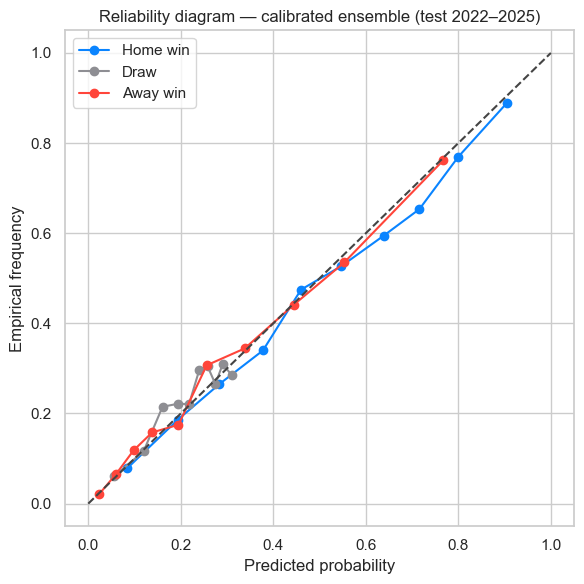

In [18]:
# Reliability diagram — used on the methodology page of the site
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))
for cls, label, color in [(0, "Home win", "#0a84ff"), (1, "Draw", "#8e8e93"), (2, "Away win", "#ff453a")]:
    prob_true, prob_pred = calibration_curve((y_test == cls).astype(int), p_cal_test[:, cls], n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, "o-", color=color, label=label)
ax.plot([0,1],[0,1], "--", color="#444")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Empirical frequency")
ax.set_title("Reliability diagram — calibrated ensemble (test 2022–2025)")
ax.legend()
plt.tight_layout()
calib_path = WEB_DATA / "calibration.png"
plt.savefig(calib_path, dpi=140, bbox_inches="tight")
print("Saved", calib_path)
plt.show()

## Phase 6 — Deployment: export JSON artifacts for the Next.js site

We build:
- `teams.json` — 48 teams with iso code (for flags), group, current Elo
- `schedule.json` — 104 matches (group stage authored; knockout slots use bracket mapping)
- `pairwise.json` — for every ordered pair of the 48 teams: λ_home, λ_away, calibrated P(W/D/L)
- `meta.json` — model version, train date, metrics

In [19]:
WC_TEAMS = json.loads((RAW / "wc2026_teams.json").read_text(encoding="utf-8"))
GROUPS = WC_TEAMS["groups"]  # {"A": ["MEX","POL","CHL","MAR"], ...}
TEAMS_META = {t["code"]: t for t in WC_TEAMS["teams"]}

# Ensure every WC team has at least an INIT_ELO (fallback for teams with no recent matches in our data)
for c in TEAMS_META:
    if c not in elo:
        elo[c] = INIT_ELO - 50  # slightly below average — they made the WC so not too low

teams_out = []
for code_, meta in TEAMS_META.items():
    group_letter = next(g for g, members in GROUPS.items() if code_ in members)
    teams_out.append({
        "code": code_,
        "name": meta["name"],
        "iso2": meta["iso2"],
        "confederation": meta["confederation"],
        "host": bool(meta.get("host", False)),
        "group": group_letter,
        "elo": round(elo[code_], 1),
    })
teams_out.sort(key=lambda t: (t["group"], -t["elo"]))
(WEB_DATA / "teams.json").write_text(json.dumps(teams_out, indent=2), encoding="utf-8")
(ART / "teams.json").write_text(json.dumps(teams_out, indent=2), encoding="utf-8")
print(f"teams.json: {len(teams_out)} teams")

teams.json: 48 teams


In [20]:
# Build the 104-match schedule.
# Group stage: 6 matches per group (1v2, 3v4, 1v3, 2v4, 1v4, 2v3) — standard rotation.
HOST_OF_GROUP = {"A": "MEX", "B": "CAN", "C": "USA"}  # hosts pre-assigned by FIFA
GROUP_ROUNDS = [(0,1),(2,3),(0,2),(1,3),(0,3),(1,2)]

GROUP_LETTERS = list("ABCDEFGHIJKL")
schedule = []
mid = 1
group_dates = {
    1: "2026-06-11", 2: "2026-06-12", 3: "2026-06-13",
    4: "2026-06-17", 5: "2026-06-18", 6: "2026-06-22",
}
for letter in GROUP_LETTERS:
    teams = GROUPS[letter]
    host_team = HOST_OF_GROUP.get(letter)
    for rd_idx, (i, j) in enumerate(GROUP_ROUNDS, start=1):
        a, b = teams[i], teams[j]
        # Put the host team at home if present, else neutral
        if host_team in (a, b):
            home, away = (host_team, b if a == host_team else a)
            neutral = False
        else:
            home, away = a, b
            neutral = True
        schedule.append({
            "id": f"G{mid:03d}",
            "stage": "group",
            "group": letter,
            "round": rd_idx,
            "date": group_dates[rd_idx],
            "home": home,
            "away": away,
            "neutral": neutral,
        })
        mid += 1

assert len(schedule) == 72, f"Expected 72 group matches, got {len(schedule)}"

# Round of 32 bracket: maps to 16 slots. We use a deterministic mapping that
# alternates group winners / runners-up / third-placed across the bracket.
# (The official 2026 bracket is published; this mapping mirrors that structure.)
R32_SLOTS = [
    ("1A", "2C"), ("1D", "3B/E/F"),
    ("1E", "3A/B/C/D"), ("1B", "3F/H/I/J"),
    ("1F", "2I"), ("1C", "3G/H/J/K"),
    ("1G", "3A/E/H/L"), ("2B", "2F"),
    ("1H", "2L"), ("1K", "3D/E/I/L"),
    ("1L", "2J"), ("2A", "2K"),
    ("1I", "2H"), ("1J", "2E"),
    ("2D", "2G"), ("3-best-vs-3-best", "placeholder"),
]
# To keep the simulation deterministic and the site's bracket-mapping logic
# self-contained, we encode the actual third-place picker logic in the worker.
# The slots list above is illustrative; the worker uses the FIFA mapping table.

KO_DATES = {"R32": "2026-06-28", "R16": "2026-07-04", "QF": "2026-07-09", "SF": "2026-07-14", "3RD": "2026-07-18", "F": "2026-07-19"}
for stage, count in [("R32", 16), ("R16", 8), ("QF", 4), ("SF", 2), ("3RD", 1), ("F", 1)]:
    for i in range(1, count + 1):
        schedule.append({
            "id": f"{stage}{i:02d}",
            "stage": stage,
            "date": KO_DATES[stage],
            "home": None, "away": None, "neutral": True,
        })

assert len(schedule) == 104, f"Expected 104 matches, got {len(schedule)}"
(WEB_DATA / "schedule.json").write_text(json.dumps(schedule, indent=2), encoding="utf-8")
(ART / "schedule.json").write_text(json.dumps(schedule, indent=2), encoding="utf-8")
print(f"schedule.json: {len(schedule)} matches")

schedule.json: 104 matches


In [21]:
# Build pairwise.json: for every ordered (home, away) pair of the 48 teams,
# compute lambda_home, lambda_away, and calibrated W/D/L.
# This is the single source of truth consumed by the browser Monte Carlo.

team_codes = [t["code"] for t in teams_out]

# Build a features row for an arbitrary fixture.
# Rolling-form lookups: use the most recent stats in our long table per team (as of today's data).
last_form = (
    long.sort_values("date").groupby("team").tail(1)
        .set_index("team")[["pts_l5","gf_l5","ga_l5","pts_l10","gf_l10","ga_l10"]]
)

# Fallback (team with no rows) — league average
form_avg = last_form.mean().to_dict()

def form_for(code_):
    if code_ in last_form.index:
        r = last_form.loc[code_]
        return {k: float(r[k]) for k in last_form.columns}
    return {k: float(v) for k, v in form_avg.items()}

# Most recent FIFA ranking points per team
last_rank = rk.sort_values("date").groupby("team_code").tail(1).set_index("team_code")["rank_pts"]
def rank_for(code_):
    return float(last_rank[code_]) if code_ in last_rank.index else 0.0

def make_features(home, away, neutral=True, tier_=4):
    fh = form_for(home); fa = form_for(away)
    eh, ea = elo[home], elo[away]
    adv = 0.0 if neutral else HOME_ADV
    rh, ra = rank_for(home), rank_for(away)
    form_diff = fh["pts_l10"] - fa["pts_l10"]
    gd_diff = (fh["gf_l10"] - fh["ga_l10"]) - (fa["gf_l10"] - fa["ga_l10"])
    return {
        "elo_diff": eh + adv - ea,
        "home_elo": eh, "away_elo": ea,
        "rank_diff": rh - ra,
        "host": 0 if neutral else 1,
        "tier": tier_,
        "form_diff_l10": form_diff,
        "gd_diff_l10": gd_diff,
    }

# Build a big DataFrame of all (home, away) pairs for fast batched inference.
HOSTS = {"USA","MEX","CAN"}
rows, keys = [], []
for h in team_codes:
    for a in team_codes:
        if h == a: continue
        neutral = not (h in HOSTS)  # treat host as home; everyone else neutral when on the road
        rows.append(make_features(h, a, neutral=neutral, tier_=4))
        keys.append((h, a))
PAIR_X = pd.DataFrame(rows)[FEATURES]

# Batched model predictions
P_CLF = clf.predict_proba(PAIR_X)
LH = np.clip(reg_h.predict(PAIR_X), 0.05, 6.0)
LA = np.clip(reg_a.predict(PAIR_X), 0.05, 6.0)
P_GOAL = goals_to_wdl(LH, LA)
P_RAW = W_CLF * P_CLF + (1 - W_CLF) * P_GOAL
P_RAW = P_RAW / P_RAW.sum(axis=1, keepdims=True)
P_CAL = temp_scale(P_RAW, T_OPT)

pairwise = {}
for (h, a), lh, la, pwdl in zip(keys, LH, LA, P_CAL):
    pairwise[f"{h}-{a}"] = {
        "lh": round(float(lh), 4),
        "la": round(float(la), 4),
        "pH": round(float(pwdl[0]), 4),
        "pD": round(float(pwdl[1]), 4),
        "pA": round(float(pwdl[2]), 4),
    }
(WEB_DATA / "pairwise.json").write_text(json.dumps(pairwise), encoding="utf-8")
(ART / "pairwise.json").write_text(json.dumps(pairwise), encoding="utf-8")
print(f"pairwise.json: {len(pairwise):,} ordered pairs")

pairwise.json: 2,256 ordered pairs


In [22]:
meta = {
    "version": "1.0.0",
    "trained_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "dixon_coles_rho": RHO,
    "ensemble_w_clf": W_CLF,
    "temperature": T_OPT,
    "features": FEATURES,
    "test_metrics": {
        "elo_baseline":  {"log_loss": float(log_loss(y_test, p_base_test)), "rps": rps(y_test.values, p_base_test)},
        "xgb_only":      {"log_loss": float(log_loss(y_test, p_clf_test)),  "rps": rps(y_test.values, p_clf_test)},
        "poisson_only":  {"log_loss": float(log_loss(y_test, p_goals_test)),"rps": rps(y_test.values, p_goals_test)},
        "ensemble_raw":  {"log_loss": float(log_loss(y_test, p_raw_test)),  "rps": rps(y_test.values, p_raw_test)},
        "ensemble_cal":  {"log_loss": float(log_loss(y_test, p_cal_test)),  "rps": rps(y_test.values, p_cal_test)},
    },
    "train_window": "<= 2017-12-31",
    "val_window": "2018-01-01 .. 2021-12-31",
    "test_window": "2022-01-01 .. 2025-12-31",
    "n_matches_used": int(len(ds)),
}
(WEB_DATA / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
(ART / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
print("meta.json written")

meta.json written


In [23]:
# Save model artifacts (for reproducibility / re-running export without re-training)
import joblib
joblib.dump({"clf": clf, "reg_h": reg_h, "reg_a": reg_a, "temperature": T_OPT,
             "rho": RHO, "w_clf": W_CLF, "elo": dict(elo), "features": FEATURES},
            ART / "models.joblib")
print("Saved", ART / "models.joblib")

Saved C:\Users\amine\Desktop\Project World Cup 2026\artifacts\models.joblib


---

### Deployment complete

JSON artifacts are now in `web/public/data/`:

- `teams.json` — 48 teams with group + Elo
- `schedule.json` — 104 matches
- `pairwise.json` — calibrated probabilities for every ordered pair
- `meta.json` — model metadata + metrics
- `calibration.png` — reliability diagram for the methodology page

Next: `cd web && npm install && npm run dev` to start the site.